In [10]:
!pip install matplotlib tensorflow scikit-learn kagglehub

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached kagglehub-1.0.1-py3-none-any.whl.metadata (40 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached kagglesdk-0.1.22-py3-none-any.whl.metadata (13 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached matplotli

In [19]:
!pip install pandas

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)

   ---------------------------------------- 0/2 [pytz]
   ---------------------------------------- 0/2 [pytz]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [panda

In [20]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU devices: []


In [21]:
import subprocess
gpu_info = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
                         capture_output=True, text=True)
print("GPU:", gpu_info.stdout.strip())

GPU: Quadro T1000


In [22]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import kagglehub

In [23]:
import gc

In [24]:
import tensorflow.keras.backend as K

In [25]:
import pandas as pd

In [26]:
from tqdm import tqdm

In [27]:
path = "D:\Human Action Recognition System\Dataset-IPN"

In [28]:
print("\nTop-level content:")
for item in os.listdir(path):
    print(" ", item)

# Videos are likely in path/videos/videos/...
video_dir = os.path.join(path, "videos", "videos")
print("\nNumber of .avi files:", len([f for f in os.listdir(video_dir) if f.endswith('.avi')]))

# Annotations folder
annot_dir = os.path.join(path, "annotations")
print("\nAnnotation folder contents:")
for item in os.listdir(annot_dir):
    print(" ", item)


Top-level content:
  annotations
  metadata.csv
  videos

Number of .avi files: 200

Annotation folder contents:
  annotations


In [29]:
code_to_gesture = {
    'B0A': 'Pointing with one finger',
    'B0B': 'Pointing with two fingers',
    'G01': 'Click with one finger',
    'G02': 'Click with two fingers',
    'G03': 'Throw up',
    'G04': 'Throw down',
    'G05': 'Throw left',
    'G06': 'Throw right',
    'G07': 'Open twice',
    'G08': 'Double click with one finger',
    'G09': 'Double click with two fingers',
    'G10': 'Zoom in',
    'G11': 'Zoom out'
}

In [30]:
target_codes = list(code_to_gesture.keys())
print("Target codes:", target_codes)

Target codes: ['B0A', 'B0B', 'G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11']


In [31]:
sample_annot_file = os.path.join(annot_dir, "1CM1_4_R__229.csv")  # adjust if naming differs
if not os.path.exists(sample_annot_file):
    # List all .csv files in annotations
    csv_files = [f for f in os.listdir(annot_dir) if f.endswith('.csv')]
    if csv_files:
        sample_annot_file = os.path.join(annot_dir, csv_files[0])
    else:
        # maybe txt files?
        txt_files = [f for f in os.listdir(annot_dir) if f.endswith('.txt')]
        if txt_files:
            sample_annot_file = os.path.join(annot_dir, txt_files[0])

In [32]:
annot_dir = os.path.join(path, "annotations")

print("=== Contents of annotations folder ===")
for root, dirs, files in os.walk(annot_dir):
    for f in files:
        print(os.path.join(root, f))
    # stop after first level if many files
    if root != annot_dir and len(files) > 10:
        break

=== Contents of annotations folder ===
D:\Human Action Recognition System\Dataset-IPN\annotations\annotations\Annot_List.txt
D:\Human Action Recognition System\Dataset-IPN\annotations\annotations\Annot_TestList.txt
D:\Human Action Recognition System\Dataset-IPN\annotations\annotations\Annot_TrainList.txt
D:\Human Action Recognition System\Dataset-IPN\annotations\annotations\classIdx.txt
D:\Human Action Recognition System\Dataset-IPN\annotations\annotations\class_details.txt
D:\Human Action Recognition System\Dataset-IPN\annotations\annotations\metadata.xlsx
D:\Human Action Recognition System\Dataset-IPN\annotations\annotations\Video_TestList.txt
D:\Human Action Recognition System\Dataset-IPN\annotations\annotations\Video_TrainList.txt


In [33]:
annot_subdir = os.path.join(annot_dir, "annotations")

# 1. classIdx.txt - probably maps gesture codes to class IDs
print("=== classIdx.txt ===")
with open(os.path.join(annot_subdir, "classIdx.txt"), "r") as f:
    print(f.read())

# 2. class_details.txt - may contain gesture names
print("\n=== class_details.txt ===")
with open(os.path.join(annot_subdir, "class_details.txt"), "r") as f:
    print(f.read())

# 3. Annot_List.txt - likely format: video_name, start_frame, end_frame, gesture_code
print("\n=== Annot_List.txt (first 20 lines) ===")
with open(os.path.join(annot_subdir, "Annot_List.txt"), "r") as f:
    for i, line in enumerate(f):
        if i < 20:
            print(line.strip())
        else:
            break

=== classIdx.txt ===
id,label
1,D0X
2,B0A
3,B0B
4,G01
5,G02
6,G03
7,G04
8,G05
9,G06
10,G07
11,G08
12,G09
13,G10
14,G11


=== class_details.txt ===
id	Label	Gesture	Instances		 
1	D0X	Non-gesture		 
2	B0A	Pointing with one finger		 
3	B0B	Pointing with two fingers		 
4	G01	Click with one finger	 
5	G02	Click with two fingers	
6	G03	Throw up	
7	G04	Throw down	
8	G05	Throw left	 
9	G06	Throw right	 
10	G07	Open twice	
11	G08	Double click with one finger	 
12	G09	Double click with two fingers	
13	G10	Zoom in	
14	G11	Zoom out	 


=== Annot_List.txt (first 20 lines) ===
video,label,id,t_start,t_end,frames
1CM1_4_R__229,D0X,1,1,17,17
1CM1_4_R__229,G11,14,18,55,38
1CM1_4_R__229,B0B,3,56,284,229
1CM1_4_R__229,G04,7,285,308,24
1CM1_4_R__229,B0B,3,309,502,194
1CM1_4_R__229,G05,8,503,544,42
1CM1_4_R__229,B0B,3,545,857,313
1CM1_4_R__229,G03,6,858,899,42
1CM1_4_R__229,B0A,2,900,1122,223
1CM1_4_R__229,D0X,1,1123,1432,310
1CM1_4_R__229,G02,5,1433,1457,25
1CM1_4_R__229,B0A,2,1458,1707,250
1CM1_4_R__229

In [34]:
annot_subdir = os.path.join(annot_dir, "annotations")
annot_list_path = os.path.join(annot_subdir, "Annot_List.txt")

df_annot = pd.read_csv(annot_list_path)
print("Total annotations:", len(df_annot))
print("Columns:", df_annot.columns.tolist())
print("\nUnique labels:", df_annot['label'].unique())

# Filter for our 13 target gesture codes (exclude D0X)
target_df = df_annot[df_annot['label'].isin(target_codes)].copy()
print(f"\nSegments with target gestures: {len(target_df)}")
print("Gesture distribution:")
print(target_df['label'].value_counts())

Total annotations: 5649
Columns: ['video', 'label', 'id', 't_start', 't_end', 'frames']

Unique labels: ['D0X' 'G11' 'B0B' 'G04' 'G05' 'G03' 'B0A' 'G02' 'G08' 'G06' 'G10' 'G09'
 'G07' 'G01']

Segments with target gestures: 4218
Gesture distribution:
label
B0A    1010
B0B    1007
G04     201
G11     200
G05     200
G03     200
G02     200
G08     200
G06     200
G10     200
G09     200
G07     200
G01     200
Name: count, dtype: int64


In [35]:
# CELL: Extract frames for the 13 target gestures
FRAME_SKIP = 5          # take 1 frame every 5 to limit data size
IMG_SIZE = 128
MAX_PER_GESTURE = 5000  # safety cap

video_folder = os.path.join(path, "videos", "videos")
target_gestures = list(code_to_gesture.values())

# Prepare accumulators
images = []
labels = []
gesture_counts = {g: 0 for g in target_gestures}

# Group annotations by video
for video_name, group in tqdm(target_df.groupby('video'), desc="Processing videos"):
    video_path = os.path.join(video_folder, video_name + ".avi")
    if not os.path.exists(video_path):
        continue

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        continue

    # Build a lookup: frame_number -> gesture name
    frame_to_gesture = {}
    for _, row in group.iterrows():
        code = row['label']
        gesture_name = code_to_gesture[code]
        t_start = int(row['t_start'])
        t_end = int(row['t_end'])
        for fn in range(t_start, t_end + 1):
            frame_to_gesture[fn] = gesture_name

    # Read video and extract frames
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx in frame_to_gesture and frame_idx % FRAME_SKIP == 0:
            gesture = frame_to_gesture[frame_idx]
            if gesture_counts[gesture] < MAX_PER_GESTURE:
                img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(gesture)
                gesture_counts[gesture] += 1
        frame_idx += 1

    cap.release()

print("\nExtraction complete. Images per gesture:")
for g, cnt in gesture_counts.items():
    print(f"  {g}: {cnt}")

Processing videos: 100%|█████████████████████████████████████████████████████████████| 200/200 [03:52<00:00,  1.16s/it]


Extraction complete. Images per gesture:
  Pointing with one finger: 5000
  Pointing with two fingers: 5000
  Click with one finger: 2238
  Click with two fingers: 2383
  Throw up: 2477
  Throw down: 2616
  Throw left: 2646
  Throw right: 2544
  Open twice: 3023
  Double click with one finger: 2696
  Double click with two fingers: 2780
  Zoom in: 2605
  Zoom out: 2569


In [36]:
images_np = np.array(images, dtype=np.uint8)   # this takes ~1.9 GB, still safe
labels_np = np.array(labels)
print("Images array shape:", images_np.shape)

Images array shape: (38577, 128, 128, 3)


In [37]:
MAX_PER_GESTURE = 1000
unique_labels = np.unique(labels_np)
keep_indices = []

for g in unique_labels:
    g_idx = np.where(labels_np == g)[0]
    if len(g_idx) > MAX_PER_GESTURE:
        keep = np.random.choice(g_idx, MAX_PER_GESTURE, replace=False)
    else:
        keep = g_idx
    keep_indices.extend(keep)

images_small_uint8 = images_np[keep_indices]
labels_small = labels_np[keep_indices]



In [38]:
del images_np, labels_np
gc.collect()

print("Final images shape (uint8):", images_small_uint8.shape)
print("Memory usage (MB):", images_small_uint8.nbytes / 1024**2)

Final images shape (uint8): (13000, 128, 128, 3)
Memory usage (MB): 609.375


In [39]:
# --- 2. Encode labels ---
le = LabelEncoder()
labels_enc = le.fit_transform(labels_small)
num_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['Click with one finger' 'Click with two fingers'
 'Double click with one finger' 'Double click with two fingers'
 'Open twice' 'Pointing with one finger' 'Pointing with two fingers'
 'Throw down' 'Throw left' 'Throw right' 'Throw up' 'Zoom in' 'Zoom out']


In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    images_small_uint8, labels_enc,
    test_size=0.2, random_state=42, stratify=labels_enc
)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}")

Train: 10400, Val: 2600


In [41]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

In [42]:
def preprocess_train(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = data_augmentation(image, training=True)
    return image, label

def preprocess_val(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

In [43]:
batch_size = 16             #32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [44]:
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [45]:
IMG_SIZE = 96

In [46]:
def attention_block(inputs, reduction_ratio=8):
    channels = K.int_shape(inputs)[-1]
    avg_pool = layers.GlobalAveragePooling2D()(inputs)
    avg_pool = layers.Reshape((1, 1, channels))(avg_pool)
    max_pool = layers.GlobalMaxPooling2D()(inputs)
    max_pool = layers.Reshape((1, 1, channels))(max_pool)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    concat = layers.Conv2D(channels // reduction_ratio, kernel_size=1,
                           activation='relu', padding='same')(concat)
    channel_att = layers.Conv2D(channels, kernel_size=1,
                                activation='sigmoid', padding='same')(concat)
    x = layers.Multiply()([inputs, channel_att])

    avg_spatial = layers.Lambda(lambda t: K.mean(t, axis=-1, keepdims=True))(x)
    max_spatial = layers.Lambda(lambda t: K.max(t, axis=-1, keepdims=True))(x)
    spatial = layers.Concatenate(axis=-1)([avg_spatial, max_spatial])
    spatial = layers.Conv2D(1, kernel_size=7, padding='same',
                            activation='sigmoid')(spatial)
    x = layers.Multiply()([x, spatial])
    return x

In [47]:
def create_model(input_shape=(128, 128, 3), num_classes=13):
    base_model = applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = True   # <--- unfreeze the whole backbone

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=True)
    x = attention_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)        # <--- new hidden layer
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    outputs = layers.Activation('softmax', dtype='float32')(outputs)
    model = keras.Model(inputs, outputs)
    return model

In [48]:
model = create_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 mobilenetv2_1.00_128 (Function  (None, 4, 4, 1280)  2257984     ['input_2[0][0]']                
 al)                                                                                              
                                                                                                  
 global_average_pooling2d (Glob  (None, 1280)        0           ['mobilenetv2_1.00_128[0][0]']   
 alAveragePooling2D)                                                                          

In [49]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [50]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

In [51]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [52]:
history = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
650/650 [==============================] - 236s 356ms/step - loss: 2.5025 - accuracy: 0.1659 - val_loss: 2.4404 - val_accuracy: 0.2265 - lr: 1.0000e-04
Epoch 2/50
650/650 [==============================] - 233s 359ms/step - loss: 2.4047 - accuracy: 0.2739 - val_loss: 2.3464 - val_accuracy: 0.3358 - lr: 1.0000e-04
Epoch 3/50
650/650 [==============================] - 260s 400ms/step - loss: 2.3310 - accuracy: 0.3491 - val_loss: 2.2993 - val_accuracy: 0.3838 - lr: 1.0000e-04
Epoch 4/50
650/650 [==============================] - 266s 409ms/step - loss: 2.2932 - accuracy: 0.3931 - val_loss: 2.2709 - val_accuracy: 0.4135 - lr: 1.0000e-04
Epoch 5/50
650/650 [==============================] - 234s 359ms/step - loss: 2.2634 - accuracy: 0.4234 - val_loss: 2.2667 - val_accuracy: 0.4204 - lr: 1.0000e-04
Epoch 6/50
650/650 [==============================] - 10445s 16s/step - loss: 2.2433 - accuracy: 0.4449 - val_loss: 2.2458 - val_accuracy: 0.4408 - lr: 1.0000e-04
Epoch 7/50
650/650 [==

In [53]:
# Save the trained model
model.save('gesture_model.h5')
print("Model saved as gesture_model.h5")

# Save the label encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("Label encoder saved as label_encoder.pkl")

Model saved as gesture_model.h5
Label encoder saved as label_encoder.pkl


In [54]:
# Mappings (copy from your earlier cells)
laptop_map = {
    "Pointing with one finger": "Move mouse (index finger tip)",
    "Pointing with two fingers": "Right click / Menu key",
    "Click with one finger": "Left click",
    "Click with two fingers": "Middle button click",
    "Throw up": "Volume up",
    "Throw down": "Volume down",
    "Throw left": "Previous tab (Ctrl+Shift+Tab)",
    "Throw right": "Next tab (Ctrl+Tab)",
    "Open twice": "Pause/Play media",
    "Double click with one finger": "Open application / Start menu",
    "Double click with two fingers": "Show desktop (Win+D)",
    "Zoom in": "Increase brightness",
    "Zoom out": "Decrease brightness"
}

math_map = {
    "Pointing with one finger": "Write/draw digit (trajectory -> number)",
    "Pointing with two fingers": 'Input "2"',
    "Click with one finger": 'Input "+"',
    "Click with two fingers": 'Input "-"',
    "Throw up": "Increase value / scroll up",
    "Throw down": "Decrease value / scroll down",
    "Throw left": "Move cursor left / backspace",
    "Throw right": "Move cursor right / space",
    "Open twice": 'Equals "=" (evaluate)',
    "Double click with one finger": 'Input "*" (multiplication)',
    "Double click with two fingers": 'Input "/" (division)',
    "Zoom in": 'Open parenthesis "("',
    "Zoom out": 'Close parenthesis ")"'
}

# Predict on a few validation samples
indices = np.random.choice(len(X_val), 5, replace=False)
sample_imgs = X_val[indices]  # uint8, 0-255
true_names = le.inverse_transform(y_val[indices])

# Preprocess & predict
sample_imgs_float = sample_imgs.astype("float32") / 255.0
pred_probs = model.predict(sample_imgs_float, verbose=0)
pred_names = le.inverse_transform(np.argmax(pred_probs, axis=1))

print("=== Gesture → Laptop Action → Math Symbol ===\n")
for i, (true, pred) in enumerate(zip(true_names, pred_names)):
    print(f"True: {true}")
    print(f"Pred: {pred}")
    print(f"   Laptop: {laptop_map.get(pred, 'Unknown')}")
    print(f"   Math:   {math_map.get(pred, 'Unknown')}")
    print()

=== Gesture → Laptop Action → Math Symbol ===

True: Throw right
Pred: Double click with two fingers
   Laptop: Show desktop (Win+D)
   Math:   Input "/" (division)

True: Click with two fingers
Pred: Pointing with one finger
   Laptop: Move mouse (index finger tip)
   Math:   Write/draw digit (trajectory -> number)

True: Pointing with one finger
Pred: Pointing with one finger
   Laptop: Move mouse (index finger tip)
   Math:   Write/draw digit (trajectory -> number)

True: Zoom in
Pred: Zoom out
   Laptop: Decrease brightness
   Math:   Close parenthesis ")"

True: Click with two fingers
Pred: Click with one finger
   Laptop: Left click
   Math:   Input "+"



In [55]:
# Full validation accuracy
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

163/163 [==============================] - 21s 129ms/step - loss: 2.0544 - accuracy: 0.6342
Validation Accuracy: 0.6342
Validation Loss: 2.0544


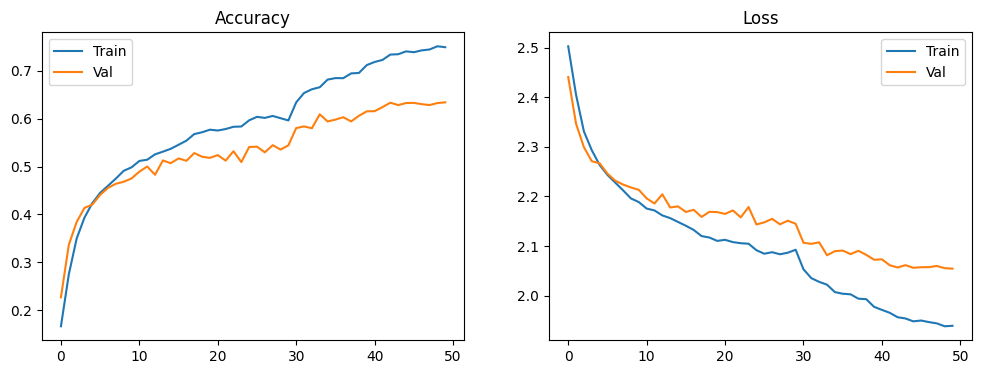

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend(); plt.title('Loss')
plt.show()

In [57]:
# Unfreeze the whole model to allow fine-tuning (if not already)
model.trainable = True

# Re‑compile with a very low learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks with more patience
early_stop_ft = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10, restore_best_weights=True
)
reduce_lr_ft = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1
)

# Fine‑tune for up to 30 epochs more
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop_ft, reduce_lr_ft]
)

Epoch 1/30
650/650 [==============================] - 266s 403ms/step - loss: 1.9288 - accuracy: 0.7601 - val_loss: 2.0510 - val_accuracy: 0.6377 - lr: 1.0000e-05
Epoch 2/30
650/650 [==============================] - 279s 429ms/step - loss: 1.9237 - accuracy: 0.7645 - val_loss: 2.0495 - val_accuracy: 0.6385 - lr: 1.0000e-05
Epoch 3/30
650/650 [==============================] - 264s 405ms/step - loss: 1.9220 - accuracy: 0.7676 - val_loss: 2.0470 - val_accuracy: 0.6438 - lr: 1.0000e-05
Epoch 4/30
650/650 [==============================] - 247s 379ms/step - loss: 1.9187 - accuracy: 0.7718 - val_loss: 2.0468 - val_accuracy: 0.6431 - lr: 1.0000e-05
Epoch 5/30
650/650 [==============================] - 247s 380ms/step - loss: 1.9202 - accuracy: 0.7693 - val_loss: 2.0429 - val_accuracy: 0.6454 - lr: 1.0000e-05
Epoch 6/30
650/650 [==============================] - 246s 377ms/step - loss: 1.9181 - accuracy: 0.7707 - val_loss: 2.0421 - val_accuracy: 0.6469 - lr: 1.0000e-05
Epoch 7/30
650/650 [==

In [58]:
model.save('gesture_model_finetuned.h5')
print("Fine‑tuned model saved.")

Fine‑tuned model saved.


In [59]:
model.save_weights('fine_weights.h5')

In [60]:
FRAME_SKIP = 5
IMG_SIZE = 128
MAX_PER_GESTURE = 10000   # effectively unlimited for this dataset

video_folder = os.path.join(path, "videos", "videos")
target_gestures = list(code_to_gesture.values())

images = []
labels = []
gesture_counts = {g:0 for g in target_gestures}

for video_name, group in tqdm(target_df.groupby('video'), desc="Extracting frames"):
    video_path = os.path.join(video_folder, video_name + ".avi")
    if not os.path.exists(video_path): continue
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): continue
    frame_to_gesture = {}
    for _, row in group.iterrows():
        if row['label'] in target_codes:
            gesture_name = code_to_gesture[row['label']]
            t_start, t_end = int(row['t_start']), int(row['t_end'])
            for fn in range(t_start, t_end+1):
                frame_to_gesture[fn] = gesture_name
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if frame_idx in frame_to_gesture and frame_idx % FRAME_SKIP == 0:
            gesture = frame_to_gesture[frame_idx]
            if gesture_counts[gesture] < MAX_PER_GESTURE:
                img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(gesture)
                gesture_counts[gesture] += 1
        frame_idx += 1
    cap.release()

Extracting frames: 100%|█████████████████████████████████████████████████████████████| 200/200 [04:17<00:00,  1.29s/it]


In [61]:
images_np = np.array(images, dtype=np.uint8)
labels_np = np.array(labels)

# LOAD the same label encoder you used before (must be the exact one)
import pickle
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

labels_enc = le.transform(labels_np)   # reuse mapping

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    images_np, labels_enc, test_size=0.2, random_state=42, stratify=labels_enc
)
del images_np, labels_np, images, labels
gc.collect()

8410

In [63]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = data_augmentation(image, training=True)
    return image, label

def preprocess_val(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

batch_size = 32
train_ds_full = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_full = train_ds_full.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_full = train_ds_full.shuffle(5000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds_full = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds_full = val_ds_full.map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_full = val_ds_full.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [64]:
model = keras.models.load_model('gesture_model_finetuned.h5')
model.trainable = True

# Low LR – we're just refining on more data
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1
)

history_full = model.fit(
    train_ds_full,
    validation_data=val_ds_full,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
1215/1215 [==============================] - 1022s 836ms/step - loss: 2.0530 - accuracy: 0.6344 - val_loss: 1.9897 - val_accuracy: 0.6982 - lr: 1.0000e-05
Epoch 2/30
1215/1215 [==============================] - 964s 792ms/step - loss: 1.9892 - accuracy: 0.6998 - val_loss: 1.9705 - val_accuracy: 0.7165 - lr: 1.0000e-05
Epoch 3/30
1215/1215 [==============================] - 1018s 837ms/step - loss: 1.9752 - accuracy: 0.7136 - val_loss: 1.9594 - val_accuracy: 0.7279 - lr: 1.0000e-05
Epoch 4/30
1215/1215 [==============================] - 1014s 833ms/step - loss: 1.9669 - accuracy: 0.7219 - val_loss: 1.9536 - val_accuracy: 0.7343 - lr: 1.0000e-05
Epoch 5/30
1215/1215 [==============================] - 1028s 845ms/step - loss: 1.9611 - accuracy: 0.7276 - val_loss: 1.9461 - val_accuracy: 0.7423 - lr: 1.0000e-05
Epoch 6/30
1215/1215 [==============================] - 1052s 865ms/step - loss: 1.9532 - accuracy: 0.7358 - val_loss: 1.9442 - val_accuracy: 0.7449 - lr: 1.0000e-05
Epoch

In [65]:
full_val_loss, full_val_acc = model.evaluate(val_ds_full)
print(f"Validation accuracy on full dataset: {full_val_acc:.4f}")
model.save('gesture_model_full.h5')

304/304 [==============================] - 67s 222ms/step - loss: 1.9071 - accuracy: 0.7806
Validation accuracy on full dataset: 0.7806


In [69]:
# ------------------------------------------------------------
# 2. Define the two action mappings
# ------------------------------------------------------------
laptop_map = {
    "Pointing with one finger": "Move mouse (index finger tip)",
    "Pointing with two fingers": "Right click / Menu key",
    "Click with one finger": "Left click",
    "Click with two fingers": "Middle button click",
    "Throw up": "Volume up",
    "Throw down": "Volume down",
    "Throw left": "Previous tab (Ctrl+Shift+Tab)",
    "Throw right": "Next tab (Ctrl+Tab)",
    "Open twice": "Pause/Play media",
    "Double click with one finger": "Open application / Start menu",
    "Double click with two fingers": "Show desktop (Win+D)",
    "Zoom in": "Increase brightness",
    "Zoom out": "Decrease brightness"
}

math_map = {
    "Pointing with one finger": "Write/draw digit (trajectory -> number)",
    "Pointing with two fingers": 'Input "2"',
    "Click with one finger": 'Input "+"',
    "Click with two fingers": 'Input "-"',
    "Throw up": "Increase value / scroll up",
    "Throw down": "Decrease value / scroll down",
    "Throw left": "Move cursor left / backspace",
    "Throw right": "Move cursor right / space",
    "Open twice": 'Equals "=" (evaluate)',
    "Double click with one finger": 'Input "*" (multiplication)',
    "Double click with two fingers": 'Input "/" (division)',
    "Zoom in": 'Open parenthesis "("',
    "Zoom out": 'Close parenthesis ")"'
}

# ------------------------------------------------------------
# 3. Webcam capture settings
# ------------------------------------------------------------
IMG_SIZE = 128
cap = cv2.VideoCapture(0)   # 0 = default camera
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess for model: convert BGR->RGB, resize, normalize
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb_frame, (IMG_SIZE, IMG_SIZE))
    input_tensor = np.expand_dims(resized, axis=0).astype('float32') / 255.0

    # Predict gesture
    pred_probs = model.predict(input_tensor, verbose=0)
    pred_idx = np.argmax(pred_probs)
    gesture = le.inverse_transform([pred_idx])[0]

    # Get the two mappings
    laptop_action = laptop_map.get(gesture, "Unknown")
    math_action = math_map.get(gesture, "Unknown")

    # Overlay information on the frame
    display_frame = frame.copy()
    cv2.putText(display_frame, f"Gesture: {gesture}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.putText(display_frame, f"Laptop: {laptop_action}", (10, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    cv2.putText(display_frame, f"Math:   {math_action}", (10, 110),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    cv2.imshow('Gesture Recognition', display_frame)

    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Press 'q' to quit.


In [2]:
!pip install mediapipe

  Using cached jax-0.6.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.6.2-cp310-cp310-win_amd64.whl.metadata (1.4 kB)
  Using cached ml_dtypes-0.5.4-cp310-cp310-win_amd64.whl.metadata (9.2 kB)
Using cached jax-0.6.2-py3-none-any.whl (2.7 MB)
Using cached jaxlib-0.6.2-cp310-cp310-win_amd64.whl (57.9 MB)
Using cached ml_dtypes-0.5.4-cp310-cp310-win_amd64.whl (210 kB)

  Attempting uninstall: ml_dtypes

    Found existing installation: ml-dtypes 0.2.0

    Uninstalling ml-dtypes-0.2.0:

      Successfully uninstalled ml-dtypes-0.2.0

   ------------- -------------------------- 1/3 [jaxlib]
   ------------- -------------------------- 1/3 [jaxlib]
   ------------- -------------------------- 1/3 [jaxlib]
   ------------- -------------------------- 1/3 [jaxlib]
   ------------- -------------------------- 1/3 [jaxlib]
   ------------- -------------------------- 1/3 [jaxlib]
   ------------- -------------------------- 1/3 [jaxlib]
   ------------- -------------------------- 1/3 [ja

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires ml-dtypes~=0.2.0, but you have ml-dtypes 0.5.4 which is incompatible.


In [1]:
import mediapipe as mp
import cv2

print("Mediapipe version:", mp.__version__)
print("OpenCV version:", cv2.__version__)

Mediapipe version: 0.10.35
OpenCV version: 4.13.0


In [4]:
# ============================================================
# Phase 1 – OpenCV hand crop + gesture model (demo_env, no MediaPipe)
# ============================================================
import cv2
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
import tensorflow.keras.backend as K

# ------------------------------------------------------------
# 1. Rebuild the model and load weights
# ------------------------------------------------------------
IMG_SIZE = 128
NUM_CLASSES = 13

def attention_block(inputs, reduction_ratio=8):
    channels = K.int_shape(inputs)[-1]
    avg_pool = layers.GlobalAveragePooling2D()(inputs)
    avg_pool = layers.Reshape((1,1,channels))(avg_pool)
    max_pool = layers.GlobalMaxPooling2D()(inputs)
    max_pool = layers.Reshape((1,1,channels))(max_pool)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    concat = layers.Conv2D(channels // reduction_ratio, kernel_size=1,
                           activation='relu', padding='same')(concat)
    channel_att = layers.Conv2D(channels, kernel_size=1,
                                activation='sigmoid', padding='same')(concat)
    x = layers.Multiply()([inputs, channel_att])
    avg_spatial = layers.Lambda(lambda t: K.mean(t, axis=-1, keepdims=True))(x)
    max_spatial = layers.Lambda(lambda t: K.max(t, axis=-1, keepdims=True))(x)
    spatial = layers.Concatenate(axis=-1)([avg_spatial, max_spatial])
    spatial = layers.Conv2D(1, kernel_size=7, padding='same',
                            activation='sigmoid')(spatial)
    x = layers.Multiply()([x, spatial])
    return x

def create_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    base_model = applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = True
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=True)
    x = attention_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model

model = create_model()
model.load_weights('fine_weights.h5')
print("Weights loaded from fine_weights.h5")

# ------------------------------------------------------------
# 2. Load label encoder
# ------------------------------------------------------------
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# ------------------------------------------------------------
# 3. OpenCV-based hand detector (background subtraction + skin)
# ------------------------------------------------------------
CONF_THRESHOLD = 0.7

# Simple skin mask using HSV range
def skin_mask(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower_skin = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin = np.array([20, 255, 255], dtype=np.uint8)
    mask1 = cv2.inRange(hsv, lower_skin, upper_skin)
    lower_skin2 = np.array([170, 20, 70], dtype=np.uint8)
    upper_skin2 = np.array([180, 255, 255], dtype=np.uint8)
    mask2 = cv2.inRange(hsv, lower_skin2, upper_skin2)
    mask = mask1 | mask2
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel)
    return mask

def get_hand_roi(frame, margin=20):
    """Return bounding rect of largest skin region or None."""
    mask = skin_mask(frame)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 3000:   # ignore tiny blobs
        return None, None
    x, y, w, h = cv2.boundingRect(largest)
    x = max(0, x - margin)
    y = max(0, y - margin)
    w = min(frame.shape[1] - x, w + 2*margin)
    h = min(frame.shape[0] - y, h + 2*margin)
    return (x, y, w, h), (x, y, w, h)   # same rect for crop and display

# ------------------------------------------------------------
# 4. Webcam loop
# ------------------------------------------------------------
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.flip(frame, 1)
    display_frame = frame.copy()

    rect, crop_rect = get_hand_roi(frame)
    gesture = "No Gesture"

    if crop_rect is not None:
        x, y, w, h = crop_rect
        if w > 0 and h > 0:
            hand_crop = frame[y:y+h, x:x+w]
            hand_crop_resized = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE))
            input_tensor = np.expand_dims(
                cv2.cvtColor(hand_crop_resized, cv2.COLOR_BGR2RGB), axis=0
            ).astype('float32') / 255.0

            probs = model.predict(input_tensor, verbose=0)[0]
            conf = np.max(probs)
            if conf >= CONF_THRESHOLD:
                gesture = le.inverse_transform([np.argmax(probs)])[0]

            # Draw rectangle around hand
            cv2.rectangle(display_frame, (x, y), (x+w, y+h), (0,255,0), 2)

    cv2.putText(display_frame, f"Gesture: {gesture}", (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow("Phase 1 - Gesture Recognition (OpenCV hand crop)", display_frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Weights loaded from fine_weights.h5
Press 'q' to quit.


In [2]:
import os, pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------- CONFIG ----------
DATASET_DIR = r"D:\Human Action Recognition System\Dataset-PSL\augmented_dataset"
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10
# -----------------------------

# 1. Gather image paths and labels
paths, labels_str = [], []
class_names = sorted(os.listdir(DATASET_DIR))
for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            paths.append(os.path.join(cls_dir, fname))
            labels_str.append(cls)

print(f"Total images: {len(paths)}, classes: {len(class_names)}")

# 2. Encode labels
le = LabelEncoder()
labels = le.fit_transform(labels_str)
num_classes = len(le.classes_)

# 3. Train/val split
train_paths, val_paths, y_train, y_val = train_test_split(
    paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# 4. Build TF datasets (no py_function)
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, y_train))
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, y_val))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 5. Build model
base_model = applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# 7. Save
model.save('psl_letter_model.h5')
with open('psl_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("Model and encoder saved.")

Total images: 34646, classes: 38
Epoch 1/10
521/867 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.6303 - loss: 1.3780

KeyboardInterrupt: 

In [1]:
import cv2
import numpy as np
import pickle
import tensorflow as tf

# ---------- LOAD MODEL & ENCODER ----------
model = tf.keras.models.load_model('psl_letter_model.h5', compile=False)
with open('psl_label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

urdu_map = {
    'Ain': '\u0639', 'Aliph': '\u0627', 'aRay': '\u0691', 'Bari yeh': '\u06D2',
    'Bay': '\u0628', 'Chay': '\u0686', 'Chhoti yeh': '\u06CC', 'Daal': '\u062F',
    'Ddaal': '\u0688', 'Dhaal': '\u0689', 'Dhuaad': '\u0636', 'Djay': '\u068F',
    'Fay': '\u0641', 'Gaaf': '\u06AF', 'Ghain': '\u063A', 'Hamza': '\u0626',
    'Hay': '\u0647', 'hey': '\u06C1', 'Jeem': '\u062C', 'Kaaf': '\u06A9',
    'Khay': '\u062E', 'Laam': '\u0644', 'Meem': '\u0645', 'Noon': '\u0646',
    'Pay': '\u067E', 'Quaaf': '\u0642', 'Ray': '\u0631', 'Seen': '\u0633',
    'Sheen': '\u0634', 'Suaad': '\u0635', 'Tay': '\u0679', 'Tey': '\u0679',
    'Thay': '\u067F', 'Toay_n': '\u06BA', 'Vao': '\u0648', 'Zay': '\u0632',
    'Zoay_n': '\u0630'
}

# Training background colour (BGR) – match #DFA78E
BG_COLOR = np.array([142, 122, 223], dtype=np.uint8)

IMG_SIZE = 128
CONF_THRESHOLD = 0.7

# ---------- Skin detection ----------
def skin_mask(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower_skin = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin = np.array([20, 255, 255], dtype=np.uint8)
    mask1 = cv2.inRange(hsv, lower_skin, upper_skin)
    lower_skin2 = np.array([170, 20, 70], dtype=np.uint8)
    upper_skin2 = np.array([180, 255, 255], dtype=np.uint8)
    mask2 = cv2.inRange(hsv, lower_skin2, upper_skin2)
    mask = mask1 | mask2
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

def apply_training_background(frame):
    mask = skin_mask(frame)
    bg = np.full_like(frame, BG_COLOR, dtype=np.uint8)
    hand = cv2.bitwise_and(frame, frame, mask=mask)
    inv_mask = cv2.bitwise_not(mask)
    bg = cv2.bitwise_and(bg, bg, mask=inv_mask)
    result = cv2.add(hand, bg)
    return result, mask

# ---------- Webcam ----------
cap = cv2.VideoCapture(0)
print("Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.flip(frame, 1)
    display_frame = frame.copy()

    processed_frame, mask = apply_training_background(frame)

    if cv2.countNonZero(mask) > 3000:
        input_img = cv2.resize(processed_frame, (IMG_SIZE, IMG_SIZE))
        input_tensor = np.expand_dims(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB), axis=0).astype('float32') / 255.0

        probs = model.predict(input_tensor, verbose=0)[0]
        conf = np.max(probs)
        if conf >= CONF_THRESHOLD:
            letter_name = le.inverse_transform([np.argmax(probs)])[0]
            urdu_char = urdu_map.get(letter_name, '?')
            gesture = f"{letter_name} ({urdu_char})"
        else:
            gesture = "No letter"
    else:
        gesture = "No hand"

    combined = np.hstack([display_frame, processed_frame])
    cv2.putText(combined, gesture, (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    cv2.imshow("PSL Recognition (left: live, right: training bg)", combined)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Press 'q' to quit.
